In [ ]:
import pandas as pd
# Graficos
import seaborn as sns
import matplotlib.pyplot as plt
# NLP
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
# Modelo
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Importacion y correccion inicil
df = pd.read_csv('/content/drive/MyDrive/Dataset/yelp_reviews.csv')
df.columns = ["sentiment","text"]
df['sentiment'] = df['sentiment'].map({1: 0, 2: 1})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37999 entries, 0 to 37998
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  37999 non-null  int64 
 1   text       37999 non-null  object
dtypes: int64(1), object(1)
memory usage: 593.9+ KB


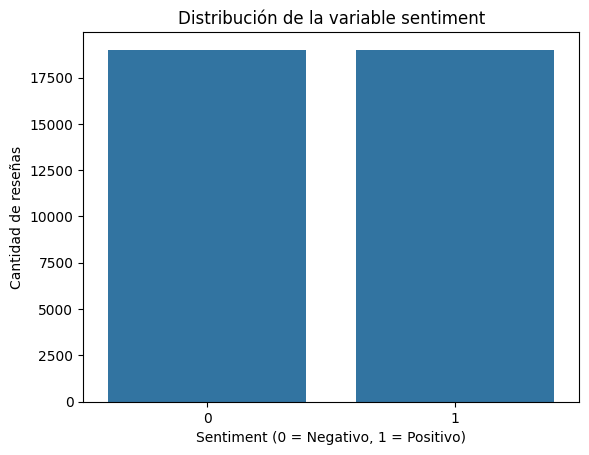

In [ ]:
# Distribucion de la variable objetivo
sns.countplot(x='sentiment', data=df)

plt.title('Distribución de la variable sentiment')
plt.xlabel('Sentiment (0 = Negativo, 1 = Positivo)')
plt.ylabel('Cantidad de reseñas')
plt.show()


In [ ]:
# Descarga de recursos necesrios para limpieza de texto
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# Procesar texto
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    clean_text = ' '.join(tokens)
    return clean_text

df['clean_text'] = df['text'].apply(preprocess_text)

In [ ]:
# Creacion del modelo
x = df['clean_text']
y = df['sentiment']

vectorizer = CountVectorizer()
x_vectorized = vectorizer.fit_transform(x)

X_train, X_test, y_train, y_test = train_test_split(x_vectorized, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

Precision del modelo: 0.9061


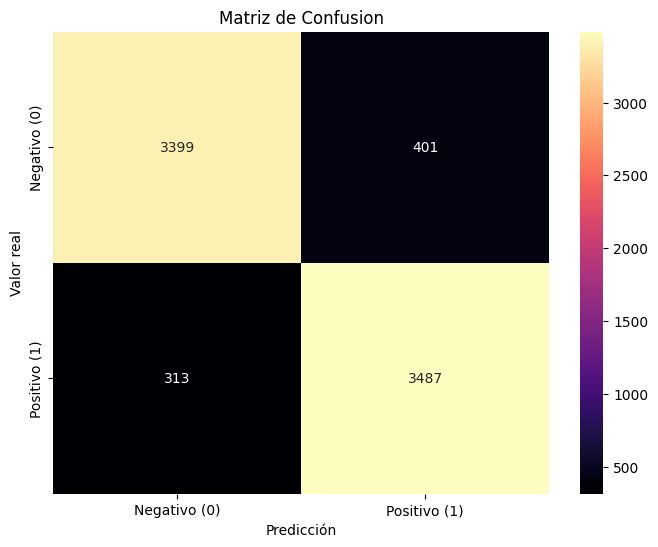

In [ ]:
# Evaluacion del modelo
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f'Precision del modelo: {accuracy:.4f}')

cnf_mtrx = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8,6))
sns.heatmap(cnf_mtrx, annot=True, fmt="d", cmap="magma",
            xticklabels=['Negativo (0)', 'Positivo (1)'],
            yticklabels=['Negativo (0)', 'Positivo (1)'])
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusion")
plt.show()

In [ ]:
# Creacion del modelo tfidf
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(x)

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

model_tfidf = LogisticRegression()
model_tfidf.fit(X_train, y_train)

LogisticRegression()

Precision del modelo: 0.9132


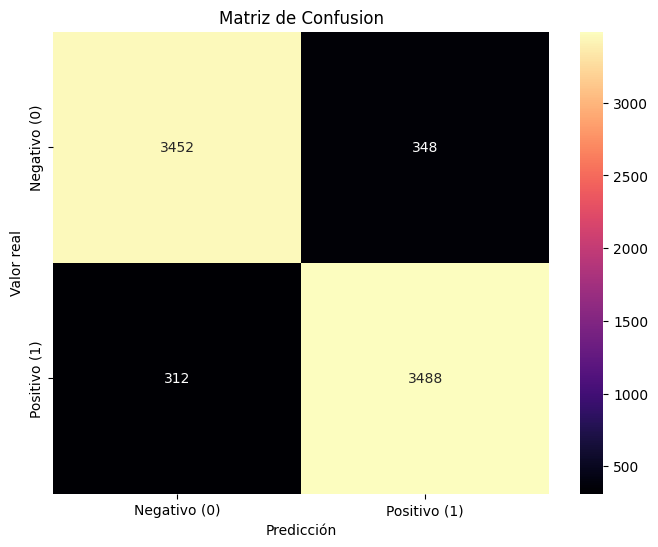

In [ ]:
# Evaluacion del modelo tfidf
y_pred_tfidf = model_tfidf.predict(X_test)

accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)
print(f'Precision del modelo: {accuracy_tfidf:.4f}')

# Matriz de confusión
cnf_mtrx_tfidf = confusion_matrix(y_test, y_pred_tfidf)

plt.figure(figsize=(8,6))
sns.heatmap(cnf_mtrx_tfidf, annot=True, fmt="d", cmap="magma",
            xticklabels=['Negativo (0)', 'Positivo (1)'],
            yticklabels=['Negativo (0)', 'Positivo (1)'])
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusion")
plt.show()

# Conclusion
Ambos modelos, tanto el de BoG (Bag of words), como el TF-IDF obtuvieron resultados bastantes buenos, en donde el modelo TF-IDF obtuvo una presicion mayor que ek BoG, por solo 0.0071%. En cuanto a un analisis del las matrices de confusion, el modelo de TF-IDF tuvo un menor numero de falsos negativos (53 menos) y falsos positivo (solo 1 sin embargo)
Al final el modelo que recomendaria a Yelp, es el modelo de TF-IDF, pues no solo tuvo mejores resultados que el BoG, asi sea por poco, sino que tambien es mas eficiente, pues la creacion y entreamiento del modelo de BoG, durante la practica, tomo entre 10 y 13 segundos, mientras que el modelo TF-IDF tomo alrededor de 4 segundos.